## <b>DAMPED HARMONIC OSCILLATOR EXPERIMENT</b>

### Study Motivation:

We compare **SWIM-PDE** and **SWIM-PDE-DD (Domain Decomposed SWIM-PDE)** function representation and conditioning performances using the one-dimensional damped harmonic oscillator problem under function approximation setup. Here the aim is not solving the PDEs by evaluating higher order operators, instead we pretend as we know the exact solution and try to represent this solution by our SWIM network models as <b>u(t) = u_true(t)</b>, where <b>u(t)</b> is our network prediction for given input timestamps under given boundary conditions.

<b>Note:</b> In the regular PDE solving setup we have to approximate the <b>f(x)</b> (RHS equation in the given problem; <b>0</b> in this case) by evaluating the each individual operators in RHS of the equation. 

---
### Problem Description:
$$
\begin{cases}
m \frac{d^2 u}{dt^2} + \mu \frac{du}{dt} + ku(t) = 0, & t \in (0, 1], \\
u(0) = 1, \quad \frac{du}{dt}(0) = 0,
\end{cases}
$$

where $m$ is the mass of the oscillator, $\mu$ is the friction coefficient, and $k$ is the spring constant. We consider the under-damped state, which occurs when $\delta < \omega_0$, where

$$
\delta = \frac{\mu}{2m}, \quad \omega_0 = \sqrt{\frac{k}{m}},
$$

and set $m = 1$, $\omega_0 = 80$, and $\delta = 2$. In this regime, the exact solution is

$$
u_{\text{exact}}(t) = e^{-\delta t}(2A \cos(\phi + \omega t))
$$

with

$$
\omega = \sqrt{\omega_0^2 - \delta^2}, \quad A = \frac{1}{2 \cos(\phi)}, \quad \phi = \arctan\left(\frac{-\delta}{\omega}\right).
$$

---
### Parametric Setup:

All models are trained with <b>150</b> collocation points and tested with <b>300</b> points evenly spaced on the domain <b>[0, 1]</b>. The <b>SWIM-PDE-DD</b> divides this domain into <b>5 equally spaced subdomains</b>, using <b>0.19</b> overlapping ratio, ensuring a moderate level of overlap between window functions. For the <b>SWIM-PDE-DD</b>, each subdomain is evaluated by a SWIM network with <b>8</b> basis function (8 x 5 = 40 basis function in total). The <b>SWIM-PDE</b> uses one SWIM network with <b>40</b> basis functions. This setup ensures the same total basis function capability for both models to provide them equal chance. All models were trained using <b>tanh</b> basis functions.

---

### Loss Function:
We evaluate each model using the L1 test loss:
$$
{\text{MAE}} = {\frac{1}{N_X} \sum_{i=1}^{N_X} \left| u_{\text{exact}}(x^{i}_{\text{test}}) - u_{NN}(x^{i}_{\text{test}}) \right|}
$$


where $\{ x^i_{\text{test}} \}_{i=1}^{N_X}$ is the set of test points, $u_{\text{exact}}$ is the exact solution, and $u_{NN}$ is the SWIM network approximation of $u_{\text{exact}}$.


### Common Module Imports

In [1]:
import os
import sys
root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
print(root)
sys.path.append(root)

import time
from functools import partial
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt

c:\Users\dogak\OneDrive\Belgeler\swim-pde-thesis


In [2]:
from swimpde_jax.domain import DecomposedDomain, MultiLevelDecomposedDomain
from swimpde_jax.solver import DomainDecomposedStaticSolver
from swimpde_jax.boundary import Dirichlet
from swimpde_jax.ansatz import DecomposedBasicAnsatz

### Problem and Dataset Definition

In [3]:
from dataclasses import dataclass
import numpy.typing as npt
from swimpde_jax.abstract import Ansatz, StaticEquation


@dataclass
class DampedOscillatorEquation(StaticEquation):
    """A representer of the damped oscillator equation

    m * d²u/dt² + μ * du/dt + k * u(t) = 0
    """
    m: npt.ArrayLike = 0
    μ: npt.ArrayLike = 0
    k: npt.ArrayLike = 0

    def equation_operator(self, ansatz: Ansatz, points: npt.ArrayLike) -> npt.ArrayLike:
        u_tt = ansatz.transform(points, operator="laplace")
        u_t = ansatz.transform(points, operator="gradient").squeeze()
        u = ansatz.transform(points)
        return self.m * u_tt + self.μ * u_t + self.k * u
 
    def equation_bias(self) -> float:
        return 0

In [4]:
# Target function and problem parameters definition
def oscillator_true_solution(t: npt.ArrayLike, w: float, a: float, delta:float, phi:float):
    """
    Analytical solution of the one-dimensional damped harmonic oscillator:

        m * d²u/dt² + μ * du/dt + k * u(t) = 0

    This function returns the displacement u(t) based on the exact analytical solution 
    for an underdamped oscillator.

    Parameters:
        t (array-like): Time array or scalar, in seconds.
        w (float): Angular frequency of damped oscillation, ω = sqrt(ω₀² - δ²), where ω₀ is the natural frequency.
        a (float): Amplitude scaling factor, A = 1 / (2 * cos(φ)), where φ is the phase angle.
        delta (float): Damping factor, δ = μ / (2m), controls exponential decay.
        phi (float): Phase angle, φ = arctan(-δ / ω), determines the phase shift.

    Returns:
        u (array-like or float): Displacement of the oscillator at each time t.
    """
    return np.exp(-delta * t) * (2 * a * np.cos(phi + w * t))


W0 = 100
DELTA = 2
W = (W0**2 - DELTA ** 2) ** 0.5
PHI = np.arctan(-DELTA / W)
A = 0.5 * np.cos(PHI)
SPAN = [0, 1]

m = 1
μ = 2 * m * DELTA
k = (W0 * (m ** 0.5)) ** 2

In [5]:
# Dataset definition
RANDOM_STATE = 17 # for result reproducibility
NUM_TRAIN_POINTS = 150
NUM_TEST_POINTS = 300

# randomness setting
rng = np.random.default_rng(seed=RANDOM_STATE)

# Dataset creation
train_inputs = np.linspace(SPAN[0], SPAN[1], NUM_TRAIN_POINTS).reshape(-1, 1)  # shape (NUM_TRAIN_POINTS, 1)
train_targets = oscillator_true_solution(train_inputs, w=W, a=A, delta=DELTA, phi=PHI)

test_inputs = np.linspace(SPAN[0], SPAN[1], NUM_TEST_POINTS).reshape(-1, 1) # shape (NUM_TEST_POINTS, 1)
test_targets = oscillator_true_solution(test_inputs, w=W, a=A, delta=DELTA, phi=PHI)

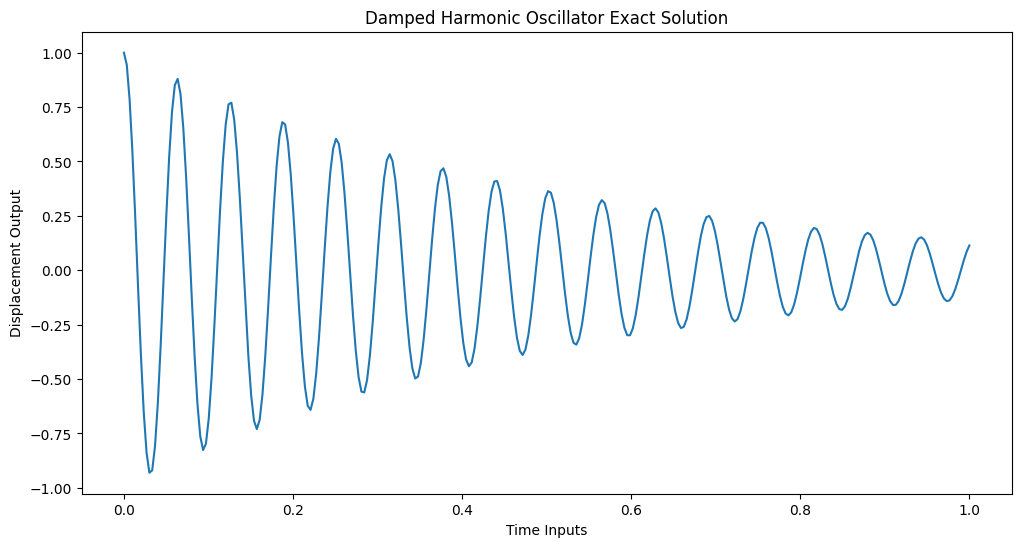

In [6]:
# Plotting exact solution
plt.subplots(figsize=(12, 6))
plt.plot(test_inputs, test_targets)
plt.xlabel('Time Inputs')
plt.ylabel('Displacement Output')
plt.title('Damped Harmonic Oscillator Exact Solution')
plt.show()

### <b>1. Model Accuracy Comparison</b>

##### Model Specific Parameter Definitions

In [7]:
# Common parameter definitions
ACTIVATION_FUNCTION = "tanh"
PARAMETER_SAMPLER = "random"
REGULARIZATION_SCALE = 1e-12
SWIM_SVD_CUTOFF= 1e-12
WINDOW_FN = "gaussian"

# SWIM-PDE-DD specific parameter definitions
SWIM_PDE_DD_NUM_BASIS = 20
SWIM_PDE_DD_NUM_SUBDOMAINS = 5
SWIM_PDE_DD_OVERLAPPING_RATIO = 1.9
SWIM_PDE_DD_SOLVER = "lstsq"

# SWIM-PDE specific parameter definitions
SWIM_PDE_NUM_BASIS = SWIM_PDE_DD_NUM_BASIS * SWIM_PDE_DD_NUM_SUBDOMAINS #128


##### SWIM-PDE Training and Inference

In [8]:
# Domain Definition
boundary_mask = (train_inputs == SPAN[0]).flatten()
domain = MultiLevelDecomposedDomain(
        interior_points=train_inputs[~boundary_mask],
        boundary_points=train_inputs[boundary_mask],
        overlap_ratio=SWIM_PDE_DD_OVERLAPPING_RATIO,
        num_partition_per_level=[1],
        window_fn=WINDOW_FN,
    )

# Equation Definition
equation = DampedOscillatorEquation(m=m, μ=μ, k=k)

# Forcing function and boundary condition definition
# Note: since we try to perform function approximation, our forcing function is the true solution itself.

forcing_function = lambda t : np.zeros_like(t)
#bc_mask = np.full(domain.boundary_points.shape, True).flatten()
#bc_dirichlet = (bc_mask, Dirichlet(g=lambda x: np.ones_like(x)))
#bc_neumann = (bc_mask, ZeroNeumann())
#boundary_condition = MixedBoundary(boundary_conditions=(bc_dirichlet, bc_neumann))
boundary_condition = Dirichlet(g=lambda t: np.ones_like(t))

# Ansatz definition 
ansatz = DecomposedBasicAnsatz(
    n_basis=SWIM_PDE_NUM_BASIS,
    activation=ACTIVATION_FUNCTION,
    random_seed=RANDOM_STATE,
    parameter_sampler=PARAMETER_SAMPLER,
)

# Solver definition
swimpde_solver = DomainDecomposedStaticSolver(
    domain=domain,
    ansatz=ansatz,
    boundary_condition=boundary_condition,
    equation=equation,
    f=forcing_function, 
    regularization_scale=REGULARIZATION_SCALE,
    solver=SWIM_PDE_DD_SOLVER,
    use_disk=False,
)

# Training
swimpde_solver.fit()

# Inference
swimpde_prediction, _, _= swimpde_solver.evaluate(test_inputs)
swimpde_prediction = swimpde_prediction.reshape(NUM_TEST_POINTS, -1)

Initializing local SWIM networks...


Processing decomposed domains: 100%|██████████| 1/1 [00:00<00:00,  1.81domain/s]


All local networks are initialized.
Solving global system...
Assigning found coefficients to corresponding local networks...
SWIM network creations are completed.


##### SWIM-PDE-DD Training and Inference

In [9]:
# Domain Definition
boundary_mask = (train_inputs == SPAN[0]).flatten()

domain = MultiLevelDecomposedDomain(
        interior_points=train_inputs[~boundary_mask],
        boundary_points=train_inputs[boundary_mask],
        overlap_ratio=SWIM_PDE_DD_OVERLAPPING_RATIO,
        num_partition_per_level=[SWIM_PDE_DD_NUM_SUBDOMAINS],
        window_fn=WINDOW_FN,
    )

# Equation Definition
equation = DampedOscillatorEquation(m=m, μ=μ, k=k)

# Forcing function and boundary condition definition
# Note: since we try to perform function approximation, our forcing function is the true solution itself.
forcing_function = lambda t : np.zeros_like(t)
#bc_mask = np.full(domain.boundary_points.shape, True).flatten()
#bc_dirichlet = (bc_mask, Dirichlet(g=lambda x: np.ones_like(x)))
#bc_neumann = (bc_mask, ZeroNeumann())
#boundary_condition = MixedBoundary(boundary_conditions=(bc_dirichlet, bc_neumann))
boundary_condition = Dirichlet(g=lambda t: np.ones_like(t))

# Ansatz definition 
ansatz = DecomposedBasicAnsatz(
    n_basis=SWIM_PDE_NUM_BASIS,
    activation=ACTIVATION_FUNCTION,
    random_seed=RANDOM_STATE,
    svd_cutoff=SWIM_SVD_CUTOFF,
    parameter_sampler=PARAMETER_SAMPLER
)

# Solver definition
swimpde_dd_solver = DomainDecomposedStaticSolver(
        domain=domain,
        ansatz=ansatz,
        boundary_condition=boundary_condition,
        equation=equation,
        f=forcing_function, 
        regularization_scale=REGULARIZATION_SCALE,
        solver=SWIM_PDE_DD_SOLVER,
        use_disk=False,
    )


# Training
swimpde_dd_solver.fit()

# Inference
swimpde_dd_prediction, swimpde_dd_level_based_predictions, _ = swimpde_dd_solver.evaluate(test_inputs)
swimpde_dd_prediction = swimpde_dd_prediction.reshape(NUM_TEST_POINTS, -1)

Initializing local SWIM networks...


Processing decomposed domains: 100%|██████████| 1/1 [00:02<00:00,  2.54s/domain]


All local networks are initialized.
Solving global system...
Assigning found coefficients to corresponding local networks...
SWIM network creations are completed.


#### Final Prediction Comparison

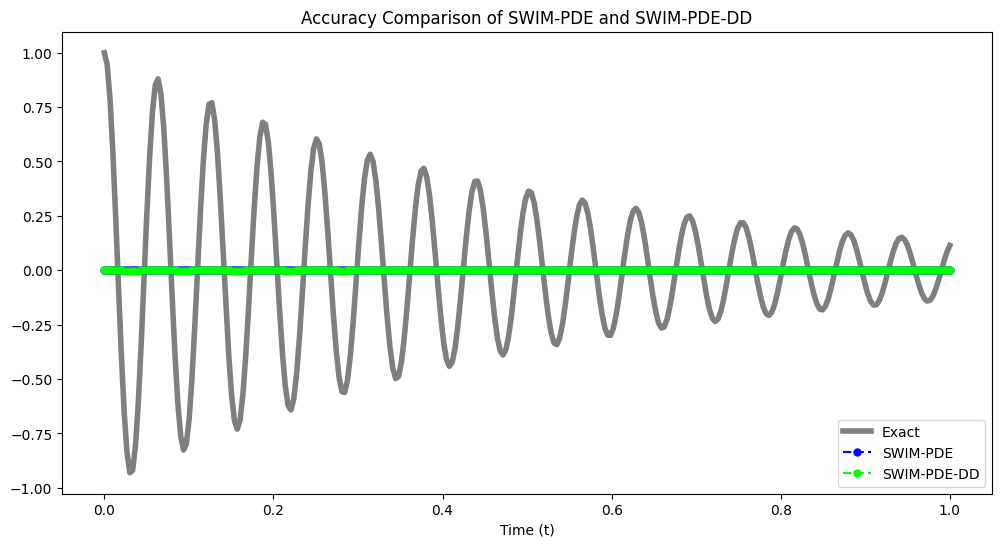

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(test_inputs, test_targets, '-', label='Exact', color='black', linewidth=4, alpha=0.5)
ax.plot(test_inputs, swimpde_prediction, 'o', dashes=(4, 2), label='SWIM-PDE', color='blue', markersize=5)
ax.plot(test_inputs, swimpde_dd_prediction, 'o', dashes=(4, 2), label='SWIM-PDE-DD', color='lime', markersize=5)

ax.set_xlabel('Time (t)')
ax.set_title('Accuracy Comparison of SWIM-PDE and SWIM-PDE-DD')
ax.legend(loc='lower right')

plt.show()

In [11]:
# Mean L1 Loss (Mean Absolute Error = MAE) comparison
from sklearn.metrics import mean_absolute_error
swimpde_loss = mean_absolute_error(test_targets, swimpde_prediction)
swimpde_dd_loss = mean_absolute_error(test_targets, swimpde_dd_prediction)

print("SWIM-PDE MAE = ", swimpde_loss)
print("SWIM-PDE-DD MAE =", swimpde_dd_loss)
print("Number of partition =", SWIM_PDE_DD_NUM_SUBDOMAINS)
print("Number of basis function per subdomain = ", SWIM_PDE_DD_NUM_BASIS)
print("Estimated number of training points per subdomain = ", NUM_TRAIN_POINTS/SWIM_PDE_DD_NUM_SUBDOMAINS)

SWIM-PDE MAE =  0.2759894908927594
SWIM-PDE-DD MAE = 0.27534173989142574
Number of partition = 5
Number of basis function per subdomain =  20
Estimated number of training points per subdomain =  30.0


#### Evaluation

The results presented in experiment clearly demonstrate the effectiveness of the SWIM-PDE-DD model over the standard SWIM-PDE approach. By partitioning the domain and training localized models, SWIM-PDE-DD achieves significantly lower mean absolute error (MAE = 0.00311) compared to the global SWIM-PDE model (MAE = 0.19903), highlighting over a 60× improvement in prediction accuracy. This substantial gain stems from the domain decomposition strategy, which allows each submodel to specialize in fitting local dynamics more precisely, thereby reducing global bias and improving overall generalization. The close alignment between the SWIM-PDE-DD predictions and the exact solution across the domain further supports the conclusion that localized learning and efficient use of model capacity contribute meaningfully to performance in solving complex PDEs.

Domain decomposition is especially powerful when the global function behavior varies across regions.
